# statlab demo: from raw bars to an out-of-sample tear sheet

This notebook walks through the full pipeline a new user would run by hand, using statlab's
Python API directly rather than the CLI: ingest synthetic data, discover a cointegrated pair,
backtest it with the M5 `PairsStrategy`, validate it out-of-sample with M6's walk-forward
harness, and render an M7 HTML tear sheet.

Every number below is a real, executed result from this run — nothing here is illustrative or
hand-typed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from statlab.data import PointInTimeUniverse, SyntheticSource, to_price_panel
from statlab.signals import discover_pairs
from statlab.backtest import BacktestEngine, PairsStrategy, Portfolio, sharpe_ratio
from statlab.validation import walk_forward_windows, run_walk_forward, combined_oos_sharpe
from statlab.report import render_tearsheet
from IPython.display import HTML

%matplotlib inline

## 1. Ingest synthetic data

`SyntheticSource` generates a panel of OU-mean-reverting cointegrated pairs plus independent
random-walk noise tickers, with a known ground truth (useful for validating discovery, but not
needed here — this notebook treats the panel like any other ingested dataset).

In [2]:
source = SyntheticSource(n=1200, n_pairs=3, n_noise=3, seed=17)
bars = source.fetch()
universe = PointInTimeUniverse.from_bars(bars)
days = universe.trading_days("1900-01-01", "2100-01-01")
print(f"{len(bars)} bars, {bars['ticker'].nunique()} tickers, {len(days)} trading days")
print(f"date range: {days[0].date()} -> {days[-1].date()}")

10800 bars, 9 tickers, 1200 trading days
date range: 2015-01-02 -> 2019-08-08


## 2. Discover cointegrated pairs

`discover_pairs` runs a correlation pre-filter, an Engle-Granger cointegration test, and a
half-life band, ranked by p-value. This is in-sample selection over the *whole* series -- fine
for a first look, but Section 4 re-does this properly, train-window-only, to avoid the
multiple-comparisons bias this in-sample step is prone to.

In [3]:
price_panel = to_price_panel(bars)
candidates = discover_pairs(price_panel, min_correlation=0.3, max_pvalue=0.1)
for c in candidates:
    print(c)

P2b~P2a beta=1.370 corr=0.62 p=0.0000 hl=14.1
P0b~P0a beta=1.653 corr=0.62 p=0.0001 hl=16.2
P1b~P1a beta=1.803 corr=0.68 p=0.0008 hl=19.8


## 3. Backtest the top pair

`PairsStrategy` wires the cointegration/Kalman/z-score signals into the event-driven
`BacktestEngine`: a causal Kalman-filtered hedge ratio, a hysteresis z-score state machine, and
realistic next-bar fills with transaction costs.

P2b~P2a  total_return=+2.87%  sharpe=0.54  fills=92  costs=3,034


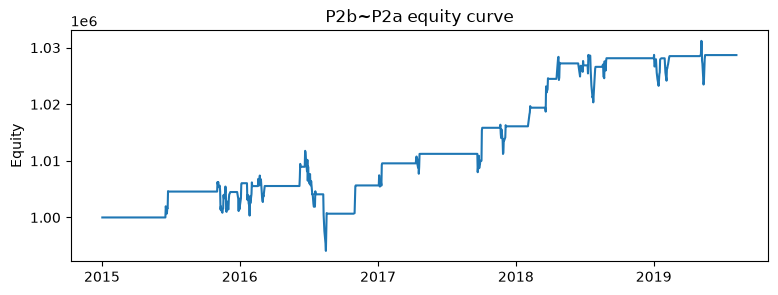

In [4]:
top = candidates[0]
strategy = PairsStrategy(top.y, top.x, notional=200_000)
engine = BacktestEngine(universe, strategy, Portfolio(1_000_000))
result = engine.run(days[0], days[-1])

print(f"{top.y}~{top.x}  total_return={result.total_return:+.2%}  "
      f"sharpe={sharpe_ratio(result.returns()):.2f}  fills={len(result.fills)}  "
      f"costs={result.total_costs:,.0f}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(result.equity_curve.index, result.equity_curve.to_numpy())
ax.set_title(f"{top.y}~{top.x} equity curve")
ax.set_ylabel("Equity")
plt.show()

## 4. Walk-forward validation

Pair *selection* here only ever sees a rolling train window; the chosen pair is backtested
strictly on the following, disjoint test window it was never selected against -- a genuinely
out-of-sample track record, not an in-sample one dressed up to look like it.

In [5]:
windows = walk_forward_windows(days, train_days=200, test_days=100)
wf_results = run_walk_forward(universe, windows, min_correlation=0.3, max_pvalue=0.1)

for r in wf_results:
    label = f"{r.window.test_start.date()} -> {r.window.test_end.date()}"
    if r.pair is None or r.result is None:
        print(f"  {label}  no pair discovered")
    else:
        print(f"  {label}  {r.pair.y}~{r.pair.x}  "
              f"return={r.result.total_return:+.2%}  "
              f"sharpe={sharpe_ratio(r.result.returns()):.2f}")

print(f"\ncombined out-of-sample Sharpe: {combined_oos_sharpe(wf_results):.2f}")

  2015-10-09 -> 2016-02-25  no pair discovered
  2016-02-26 -> 2016-07-14  P1b~P1a  return=+1.20%  sharpe=2.15
  2016-07-15 -> 2016-12-01  P1b~P1a  return=+0.92%  sharpe=2.10
  2016-12-02 -> 2017-04-20  P1b~P1a  return=+0.73%  sharpe=1.14
  2017-04-21 -> 2017-09-07  P2b~P2a  return=+0.00%  sharpe=0.00
  2017-09-08 -> 2018-01-25  P1b~P1a  return=+0.27%  sharpe=0.67
  2018-01-26 -> 2018-06-14  P2b~P2a  return=+1.11%  sharpe=2.29
  2018-06-15 -> 2018-11-01  P0b~P0a  return=+0.00%  sharpe=0.00
  2018-11-02 -> 2019-03-21  P0b~P0a  return=-0.10%  sharpe=-0.23
  2019-03-22 -> 2019-08-08  no pair discovered

combined out-of-sample Sharpe: 1.19


## 5. Render the HTML tear sheet

The same `report.render_tearsheet` the CLI's `backtest-pair --report` flag uses -- a
self-contained HTML report (stats table + equity/drawdown/return-distribution charts, all
embedded as base64 PNGs) for the single-pair backtest from Section 3.

tear sheet: 82,757 chars, 3 embedded charts



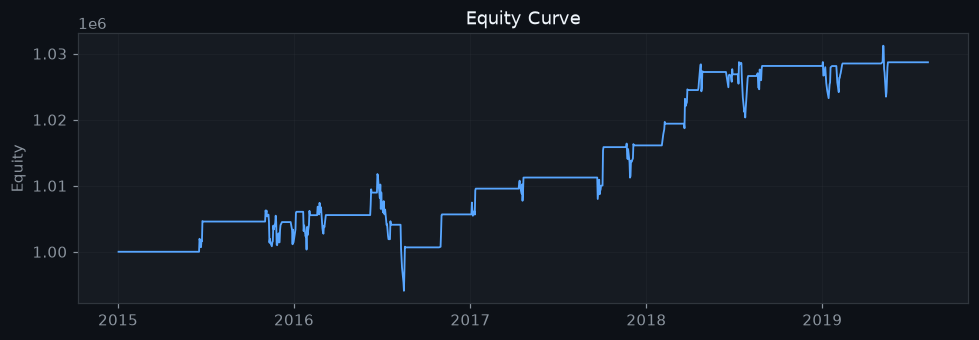
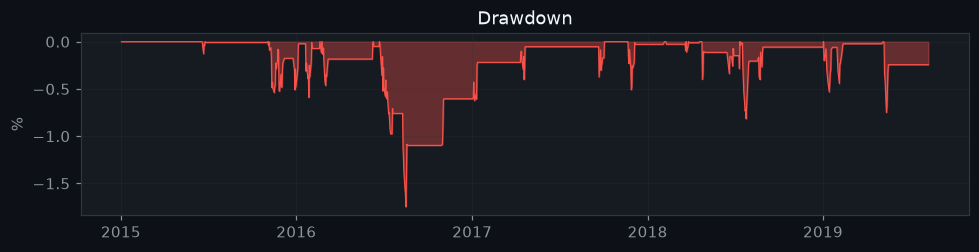
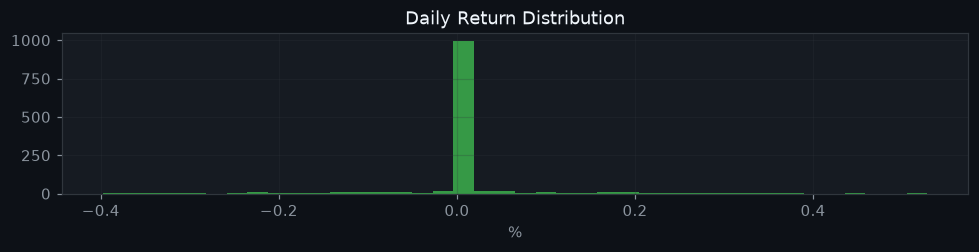

In [6]:
html = render_tearsheet(result, title=f"{top.y}~{top.x} Pairs Backtest")
print(f"tear sheet: {len(html):,} chars, {html.count('base64')} embedded charts")
HTML(html)